# ToLD-Br — Análise Exploratória Inicial

Exploração inicial do conjunto **Toxic Language Detection in Brazilian Portuguese** (Leite et al. 2020): 21.000 tweets em português brasileiro anotados em seis categorias de dano (`homophobia`, `obscene`, `insult`, `racism`, `misogyny`, `xenophobia`). Cada categoria possui um **escore ordinal 0–3** = número de anotadores (de três) que sinalizaram o tweet.

**Objetivos**
1. Confirmar dimensões, esquema e valores ausentes em `train.csv`.
2. Quantificar o desbalanceamento de classes sob a visão ordinal e sob a regra de maioria (`votos ≥ 2`) — motiva a alocação estratificada.
3. Caracterizar a estrutura multi-rótulo (com que frequência um tweet recebe positivos em múltiplas categorias).
4. Descrever o comprimento dos textos para servir de baseline à engenharia de *features* posteriores (`word_count`, `caps_ratio`, `punc_density`).
5. Inspecionar exemplos dos estratos mais raros (`xenophobia`, `racism`).

Executar após o download do dataset (ver README — comando único via biblioteca `datasets`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = REPO_ROOT / "data" / "raw" / "told-br" / "train.csv"
FIG_DIR = REPO_ROOT / "data" / "processed" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["homophobia", "obscene", "insult", "racism", "misogyny", "xenophobia"]

pd.set_option("display.max_colwidth", 140)
RAW_PATH

PosixPath('/Users/hugohonda/Developer/toptal/toxicity-analysis/data/raw/told-br/train.csv')

## 1. Carregamento e inspeção do esquema

In [2]:
df = pd.read_csv(RAW_PATH)
print(f"dimensões: {df.shape}")
df.dtypes

dimensões: (21000, 7)


text            str
homophobia    int64
obscene       int64
insult        int64
racism        int64
misogyny      int64
xenophobia    int64
dtype: object

In [3]:
df.head(3)

,text,homophobia,obscene,insult,racism,misogyny,xenophobia
0,"Meu nivel de amizade com isis é ela ter meu insta e eu ter o dela, e quando eu penso que não ela manda mensagem “ falano otario ta falan...",0,0,2,0,0,0
1,"rt @user @user o cara adultera dados, que foram desmascarados e ainda quer ficar no governo?",0,0,1,0,0,0
2,"@user @user @user o cara só é simplesmente o maior vencedor da história de futebol, tá com 36 anos e tem gás demais e não um gordo com j...",0,2,1,0,0,0


## 2. Valores ausentes

O ToLD-Br é geralmente limpo, mas reportamos explicitamente conforme exigência metodológica.

In [4]:
ausentes = df.isna().sum()
ausentes_pct = (ausentes / len(df) * 100).round(4)
pd.DataFrame({"ausentes": ausentes, "ausentes_pct": ausentes_pct})

,ausentes,ausentes_pct
text,0,0.0
homophobia,0,0.0
obscene,0,0.0
insult,0,0.0
racism,0,0.0
misogyny,0,0.0
xenophobia,0,0.0


## 3. Distribuição da contagem de votos por categoria

Cada rótulo assume valores inteiros em `{0, 1, 2, 3}`. A célula 0 domina todas as colunas; as células superiores são exatamente os estratos raros que nos interessa preservar na amostragem. Contagens absolutas por (categoria, votos):

In [5]:
vote_dist = pd.DataFrame(
    {label: df[label].value_counts().reindex(range(4), fill_value=0) for label in LABELS}
).T
vote_dist.columns = [f"votos_{c}" for c in vote_dist.columns]
vote_dist["total"] = vote_dist.sum(axis=1)
vote_dist

,votos_0,votos_1,votos_2,votos_3,total
homophobia,20656,168,102,74,21000
obscene,14348,4249,1791,612,21000
insult,16615,2516,1352,517,21000
racism,20862,105,27,6,21000
misogyny,20537,330,104,29,21000
xenophobia,20849,109,27,15,21000


## 4. Binarização por maioria de votos

A maior parte dos artigos sobre ToLD-Br adota `rótulo_bin = (votos ≥ 2)` — pelo menos 2 dos 3 anotadores sinalizaram o tweet. Esta é a classe positiva operacional. Frequências sob essa regra:

In [6]:
binario = (df[LABELS] >= 2).astype(int)
binario.columns = [f"{c}_pos" for c in binario.columns]
df_bin = pd.concat([df, binario], axis=1)

pos_counts = binario.sum().sort_values(ascending=False)
pos_counts.index = [c.replace("_pos", "") for c in pos_counts.index]
pos_pct = (pos_counts / len(df) * 100).round(3)
label_summary = pd.DataFrame({"positivos": pos_counts, "pct_corpus": pos_pct})
label_summary

,positivos,pct_corpus
obscene,2403,11.443
insult,1869,8.900
homophobia,176,0.838
misogyny,133,0.633
xenophobia,42,0.200
racism,33,0.157


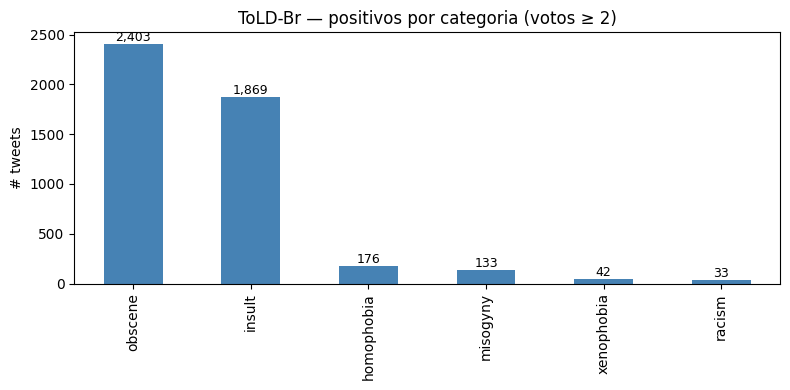

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
pos_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("ToLD-Br — positivos por categoria (votos ≥ 2)")
ax.set_ylabel("# tweets")
ax.set_xlabel("")
for i, v in enumerate(pos_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "toldbr_label_counts.png", dpi=150)
plt.show()

## 5. Estrutura multi-rótulo

Quantas categorias cada tweet aciona sob a regra `votos ≥ 2`? A maioria dos tweets é limpa; entre os positivos, os padrões de coocorrência importam para o desenho da estratificação.

In [8]:
df_bin["n_rotulos"] = binario.sum(axis=1)
n_label_dist = df_bin["n_rotulos"].value_counts().sort_index()
pd.DataFrame({
    "tweets": n_label_dist,
    "pct": (n_label_dist / len(df_bin) * 100).round(3),
})

,tweets,pct
n_rotulos,,
0,16937,80.652
1,3510,16.714
2,515,2.452
3,37,0.176
5,1,0.005


In [ ]:
any_pos = (df_bin["n_rotulos"] > 0).mean() * 100
print(
    f"taxa de qualquer positivo (votos ≥ 2): {any_pos:.2f}%"
    f"   |   taxa limpa: {100 - any_pos:.2f}%"
)

## 6. Baseline de comprimento dos textos

Estatísticas descritivas de contagens de caracteres e palavras, segmentadas entre tweets limpos e tweets com qualquer positivo. Antecipa as *features* `word_count` e `caps_ratio` do próximo notebook.

In [10]:
df_bin["qtd_caracteres"] = df_bin["text"].str.len()
df_bin["qtd_palavras"] = df_bin["text"].str.split().str.len()
df_bin["qualquer_positivo"] = df_bin["n_rotulos"] > 0

df_bin.groupby("qualquer_positivo")[["qtd_caracteres", "qtd_palavras"]].describe().round(1)

qtd_caracteres                                             \
                           count  mean   std  min   25%   50%    75%    max   
qualquer_positivo                                                             
False                    16937.0  86.9  66.1  4.0  40.0  66.0  110.0  326.0   
True                      4063.0  86.1  65.5  6.0  40.0  65.0  110.0  367.0   

                  qtd_palavras                                          
                         count  mean   std  min  25%   50%   75%   max  
qualquer_positivo                                                       
False                  16937.0  15.6  11.7  1.0  7.0  12.0  20.0  67.0  
True                    4063.0  15.7  11.7  1.0  7.0  12.0  20.0  63.0

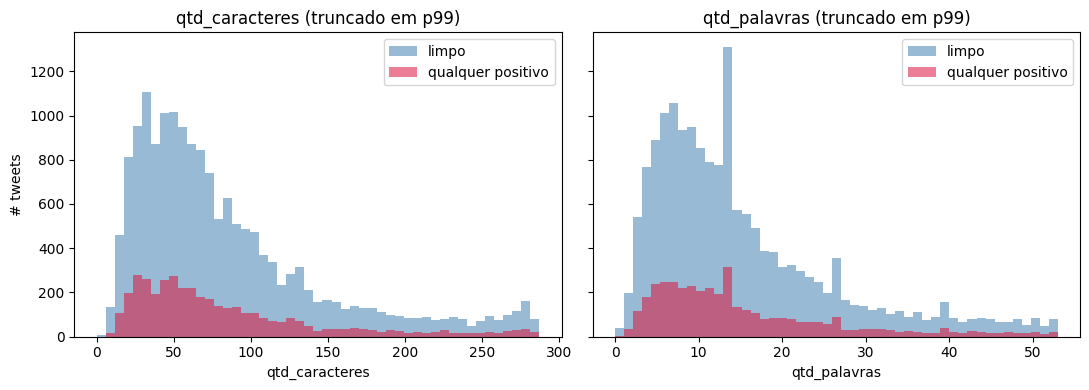

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col in zip(axes, ["qtd_caracteres", "qtd_palavras"], strict=True):
    upper = df_bin[col].quantile(0.99)
    bins = np.linspace(0, upper, 50)
    limpo = df_bin.loc[~df_bin["qualquer_positivo"], col]
    pos = df_bin.loc[df_bin["qualquer_positivo"], col]
    ax.hist(limpo, bins=bins, alpha=0.55, label="limpo", color="steelblue")
    ax.hist(pos, bins=bins, alpha=0.55, label="qualquer positivo", color="crimson")
    ax.set_title(f"{col} (truncado em p99)")
    ax.set_xlabel(col)
    ax.legend()
axes[0].set_ylabel("# tweets")
fig.tight_layout()
fig.savefig(FIG_DIR / "toldbr_length_distributions.png", dpi=150)
plt.show()

## 7. Exemplos dos estratos raros

Algumas linhas de `xenophobia` e `racism` (categorias mais raras) sob o limiar estrito `votos == 3`, para validar visualmente os rótulos e a codificação do texto.

In [12]:
for stratum in ["xenophobia", "racism"]:
    estrito = df[df[stratum] == 3]
    maioria = df[df[stratum] >= 2]
    print(f"--- {stratum}: votos==3 n={len(estrito)},  votos>=2 n={len(maioria)} ---")
    pool = estrito if len(estrito) else maioria
    amostra = pool.sample(min(3, len(pool)), random_state=42)
    for _, row in amostra.iterrows():
        text = row["text"].replace("\n", " ")[:240]
        print(f"  · {text}")
    print()

--- xenophobia: votos==3 n=15,  votos>=2 n=42 ---
  · @user @user Carla esse chinezinho falsificado e um pilantra. Não se deixa enganar como ele enganou os que votaram nele. Esse tipo de jumento só se elege uma vez. Kim . Frota. E outros do MBL
  · torava todas essas japinha
  · aposto que é coisa de carioca ou de paulista pq porra só a gente pra fazer essas merdas

--- racism: votos==3 n=6,  votos>=2 n=33 ---
  · Segue minha página de shitpost @user Mas é de humor negro/shitpost então se tu não gosta sai  Eu divido essa página com a minha melhor amiga segue ela tbm @user :&gt;
  · @user @user fala barro preto!!!!!!!!!!!
  · vai toma no cu raça desgraçada



## Próximos passos

- Codificar as estatísticas populacionais acima como tabela-base contra a qual o módulo de amostragem comparará a amostra estratificada.
- Implementação atual em `src/toxicity_analysis/sampling.py` já contém `calc_cochran(N, e=0.05, conf=0.95)` e amostragem estratificada proporcional. Para N=21.000, n₀≈385 → n com correção de população finita ≈ 378.
- *Features* léxicas (`word_count`, `unique_word_ratio`, `caps_ratio`, `punc_density`, `mean_word_length`) já foram movidas para `src/toxicity_analysis/features.py` (ver notebook `02`).
- Para análise via TF-IDF nos estratos raros (`racism`, `xenophobia`) usar *stopwords* portuguesas (`nltk.corpus.stopwords.words('portuguese')`).